# Explore here

Campaña de Marketing Bancario
Comprensión empresarial

Los depósitos a largo plazo permiten a los bancos retener dinero durante un período de tiempo específico, lo que permite al banco utilizar ese dinero para mejorar sus inversiones. Las campañas de marketing de este producto se basan en llamadas telefónicas. Si un usuario no se encuentra disponible en un momento dado, entonces se le volverá a llamar de nuevo en otro momento.

Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

Para abordar este problema crearemos un algoritmo de clasificación que ayude a predecir si un cliente contratará o no un depósito a largo plazo.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre bank-marketing-campaign-data.csv, y puedes cargarlo en el código directamente desde el siguiente enlace:


PARTE 1

1. CONOCIENDO EL DATASET

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

#Data collection
df = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv",sep=";")



df.info()
print("--------------------------------------------------------------------------------------")
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
# revisando nulos
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Conclusiones del dataset:
- el dataset tiene 41188 filas y 21 columnas
- No hay valores nulos
- Se visualizan 11 variables categóricas y 10 vairables numéricas.

2. ELIMINACIÓN DE DUPLICADOS

In [5]:
duplicados = df.duplicated()
num_duplicados = duplicados.sum()

print(f"El dataset tiene {num_duplicados} filas duplicadas")

#si hubiera filas duplicadas 
#seleccionar duplicados
df_duplicados = df[duplicados]
print("Filas duplicadas:")
print(df_duplicados)

# Eliminar duplicados
#usar el método drop.duplicated() para eliminar filas duplicadas

df = df.drop_duplicates().reset_index(drop=True)

print ("="*80)

print(f"Shape sin duplicados: {df.shape}")

El dataset tiene 12 filas duplicadas
Filas duplicadas:
       age          job   marital            education  default housing loan  \
1266    39  blue-collar   married             basic.6y       no      no   no   
12261   36      retired   married              unknown       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
16956   47   technician  divorced          high.school       no     yes   no   
18465   32   technician    single  professional.course       no     yes   no   
20216   55     services   married          high.school  unknown      no   no   
20534   41   technician   married  professional.course       no     yes   no   
25217   39       admin.   married    university.degree       no      no   no   
28477   24     services    single          high.school       no     yes   no   
32516   35       admin.   married    university.degree       no     yes   no   
36951   45       admin.   married    university.degree       no  

conclusión:
Se eliminaron 12 filas duplicadas, ahora el df tiene  41176 registros.

3. Selección de atributos relevantes

In [6]:
#-------------------------3. Selección de atributos relevantes-------------------
df.drop(["duration","day_of_week"], axis = 1, inplace = True)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


conclusión: se quitan las variables duration y day_of_week ya que con campos que dan característica de la llamada, se cree que la duración de la llamada no se puede predecir, y tmbn el día de la semana que se contacta al cliente no tendría tanta relevancia a la hora de definir si contrata un depósito, 

4. Análisis univariante

In [7]:
#chequeo de campos en df
df.info()
print("==============================================================")
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 41176 entries, 0 to 41175
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  str    
 2   marital         41176 non-null  str    
 3   education       41176 non-null  str    
 4   default         41176 non-null  str    
 5   housing         41176 non-null  str    
 6   loan            41176 non-null  str    
 7   contact         41176 non-null  str    
 8   month           41176 non-null  str    
 9   campaign        41176 non-null  int64  
 10  pdays           41176 non-null  int64  
 11  previous        41176 non-null  int64  
 12  poutcome        41176 non-null  str    
 13  emp.var.rate    41176 non-null  float64
 14  cons.price.idx  41176 non-null  float64
 15  cons.conf.idx   41176 non-null  float64
 16  euribor3m       41176 non-null  float64
 17  nr.employed     41176 non-null  float64
 1

(41176, 19)

4.1. Análisis sobre variables categóricas

In [8]:
# ---------------------------Análisis sobre variables categóricas
# revisión de valores repetidos por:
print(df.default.value_counts())
print("="*80)
print(df.housing.value_counts())
print("="*80)
print(df.loan.value_counts())
print("="*80)
print(df.contact.value_counts())


default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64
housing
yes        21571
no         18615
unknown      990
Name: count, dtype: int64
loan
no         33938
yes         6248
unknown      990
Name: count, dtype: int64
contact
cellular     26135
telephone    15041
Name: count, dtype: int64


In [9]:
# Ver cuántos valores únicos y cuáles son
print(f"valores únicos:",df['job'].nunique())      # solo el número
print("="*50)
print(df['job'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 12
job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64


/tmp/ipykernel_994/1323932437.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)  #ajustar nombres de etiquetas en education


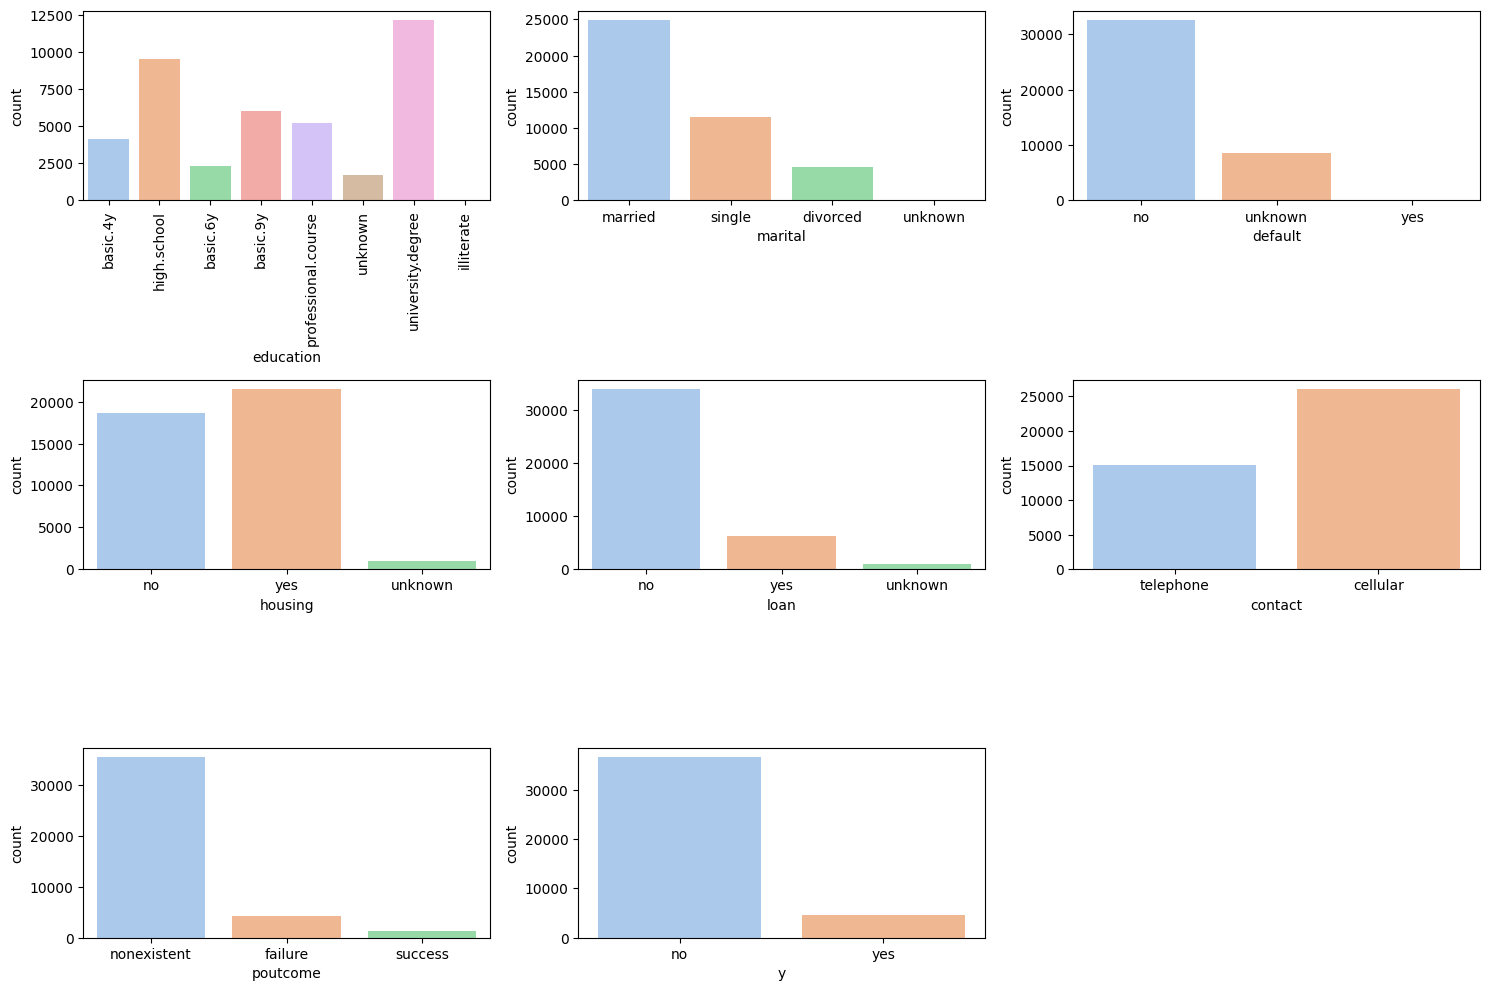

In [10]:
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.countplot(ax = axis[0, 0], data = df, x = "education", palette='pastel', hue= "education", legend=False)
sns.countplot(ax = axis[0, 1], data = df, x = "marital", palette='pastel', hue= "marital", legend=False)
sns.countplot(ax = axis[0, 2], data = df, x = "default", palette='pastel', hue= "default", legend=False)
sns.countplot(ax = axis[1, 0], data = df, x = "housing", palette='pastel', hue= "housing", legend=False)
sns.countplot(ax = axis[1, 1], data = df, x = "loan", palette='pastel', hue= "loan", legend=False)
sns.countplot(ax = axis[1, 2], data = df, x = "contact", palette='pastel', hue= "contact", legend=False)
sns.countplot(ax = axis[2, 0], data = df, x = "poutcome", palette='pastel', hue= "poutcome", legend=False)
sns.countplot(ax = axis[2, 1], data = df, x = "y", palette='pastel', hue= "y", legend=False)

axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)  #ajustar nombres de etiquetas en education
axis[2, 2].set_visible(False)  
# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

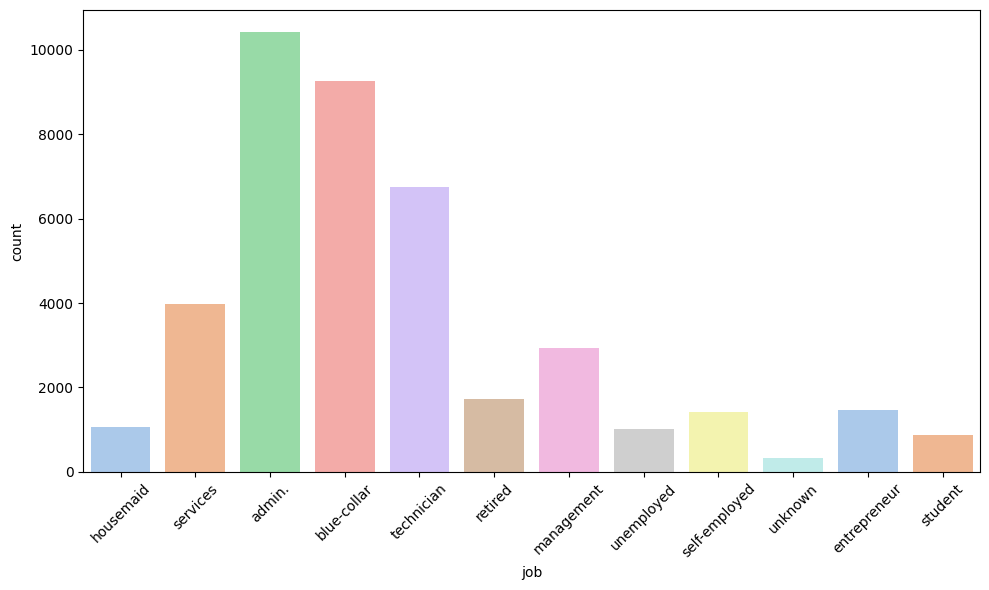

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="job", palette='pastel', hue="job", legend=False, ax=ax)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

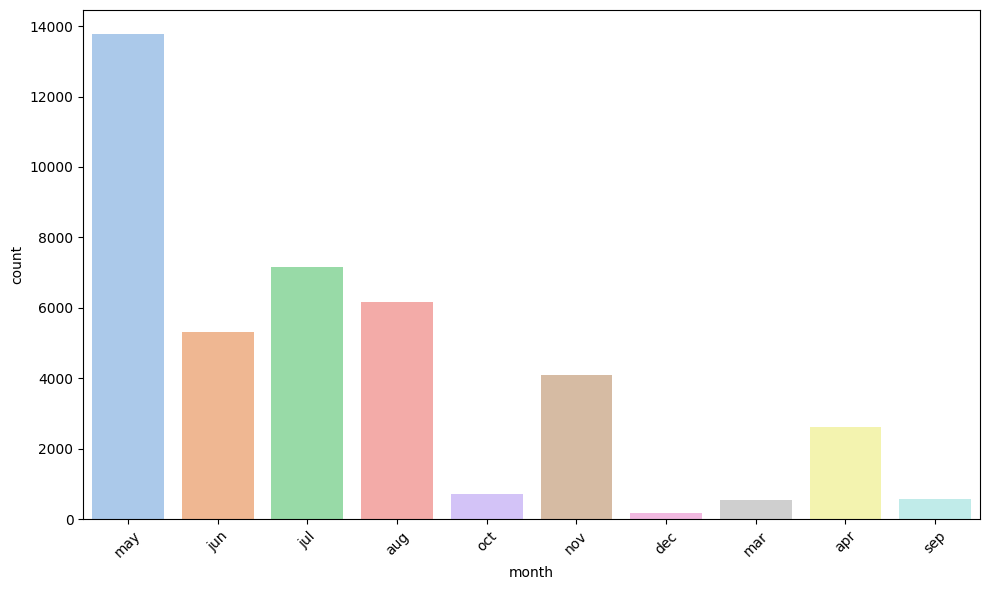

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=df, x="month", palette='pastel', hue="month", legend=False, ax=ax)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

conclusiones:
- education: La categoría más frecuente es university_degree, seguido de high school. Esto indica que la mayoría de los clientes tienen un nivel educativo universitario.
- marital: La mayoría de los clientes son casados.
- default: La gran mayoría tienen valor no, lo que significa que casi ningún cliente tiene crédito actualmente.
- housing: Se visualiza un reparto bastante equilibrado entre los que si tienen si tienenn préstamo de vivienda y los que no.
- loan: La mayoría de clientes no tiene préstamo personal, considedrando que son más de 30mil clientes (según gráfico)
- contact: El método de contacto más usado es el celular.
- poutcome: La mayoría de clientes tiene valor no existente, lo que significa que la mayoría de los clientes son nuevos (no han contactado antes). Solo un pequeño porcentaje tuvo éxito en campañas anteriores.
- y: Según el dataset, la mayoría de clientes que respondieron no a obtener un depósito a largo plazo.
- job: La mayoría de clientes tienen ocupación de tipo admin. seguido de blue-collar.
- month: Se puede decir que mayo es el mes con más contactos con el cliente. 

4.2. Análisis sobre variable numéricas

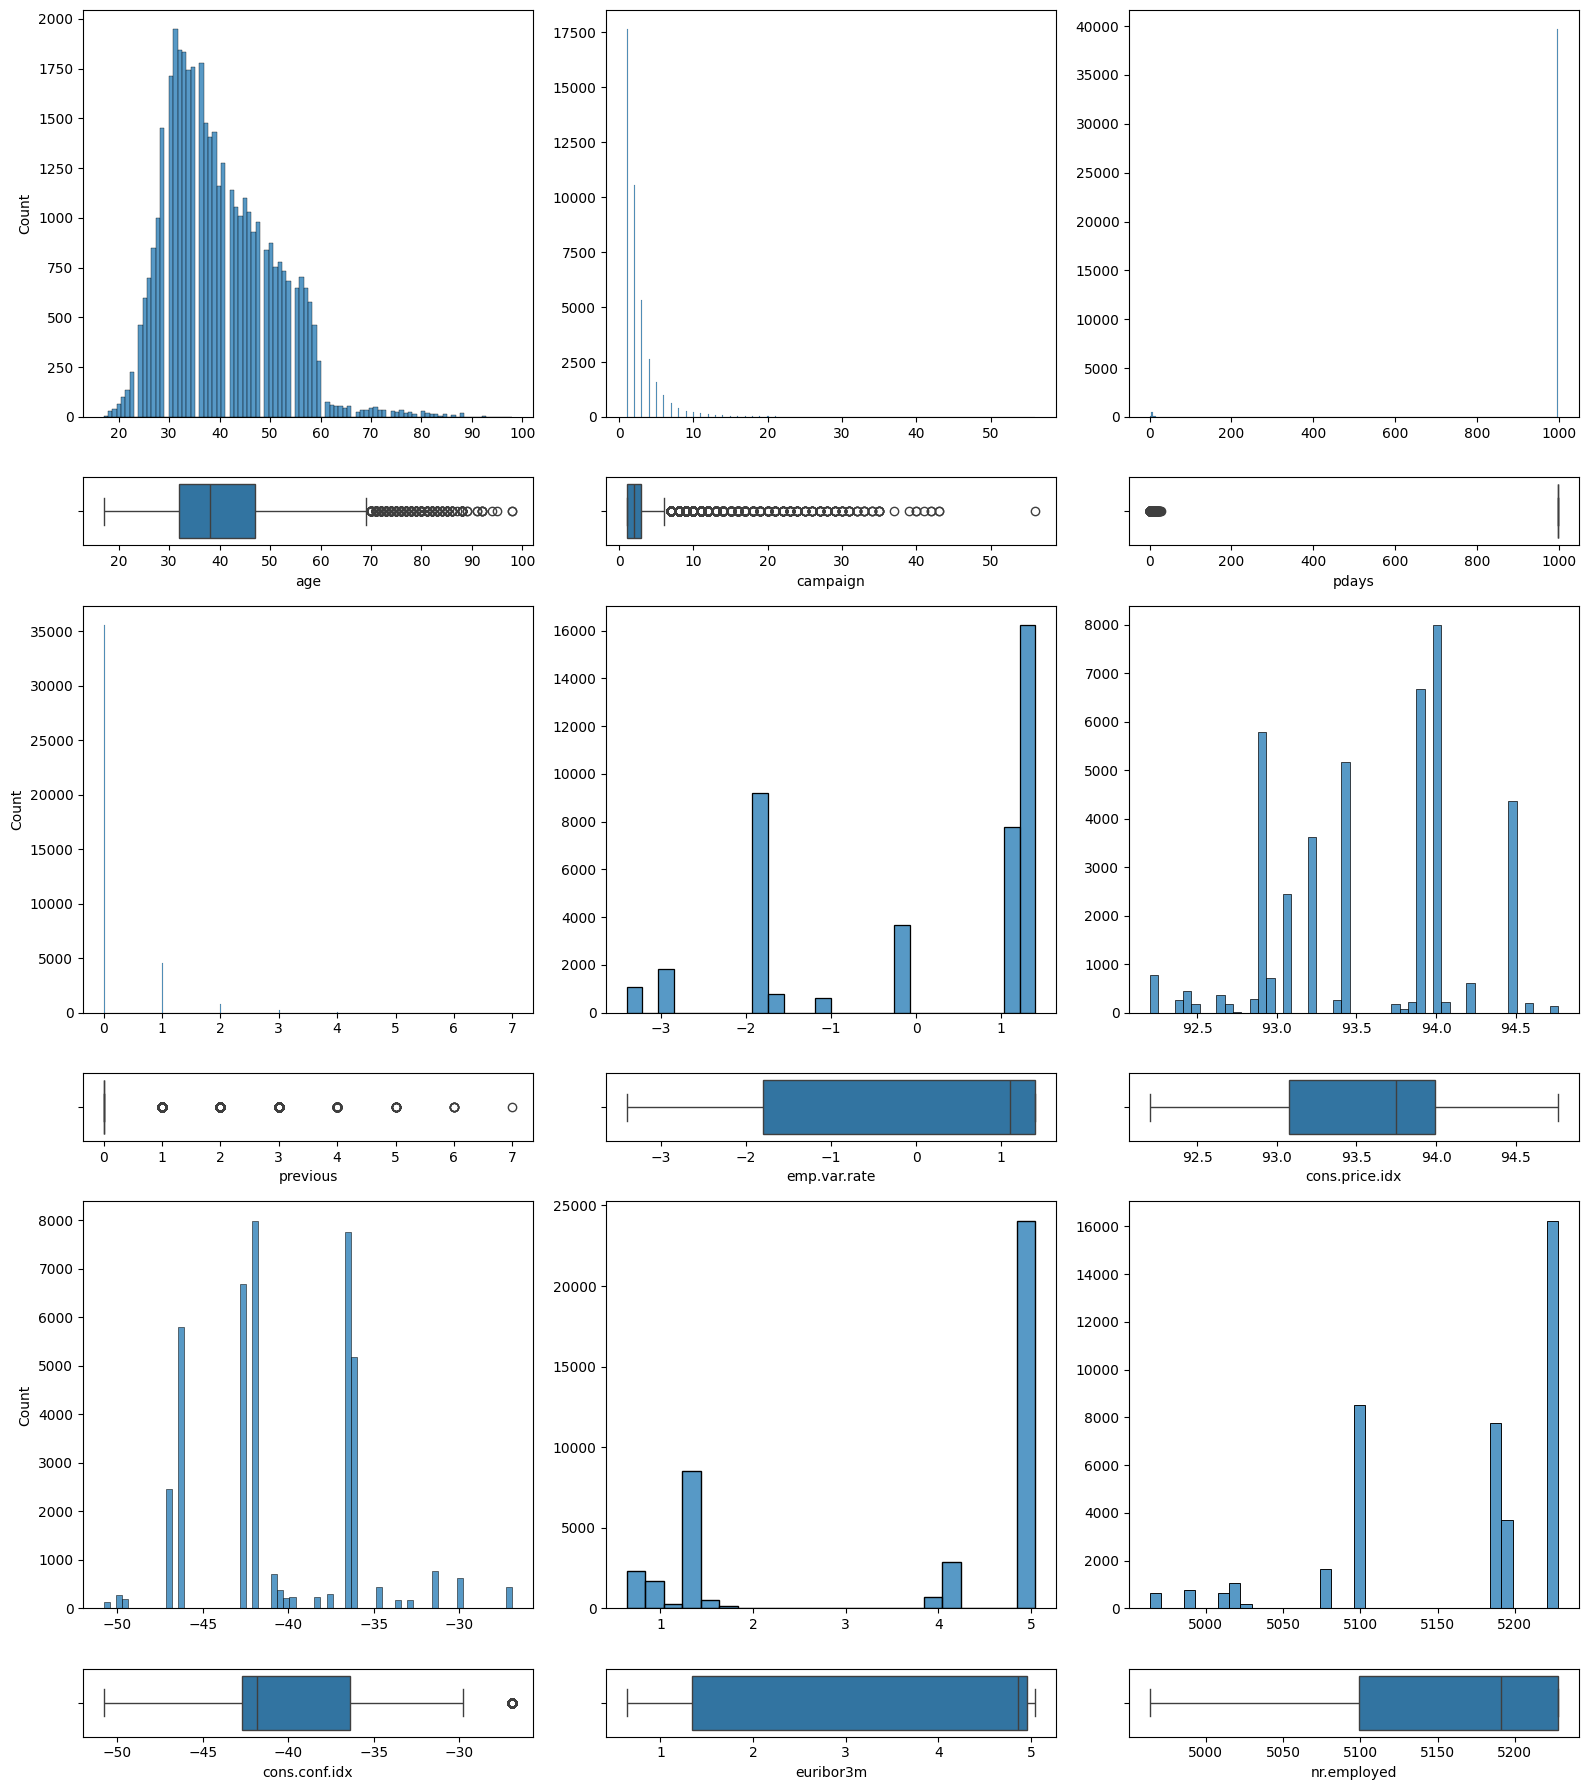

In [13]:
fig, axis = plt.subplots(6, 3, figsize=(16, 18), gridspec_kw={'height_ratios': [6, 1, 6, 1, 6, 1]})

# age
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")

# campaign
sns.histplot(ax=axis[0, 1], data=df, x="campaign").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="campaign")

# pdays
sns.histplot(ax=axis[0, 2], data=df, x="pdays").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="pdays")

# previous
sns.histplot(ax=axis[2, 0], data=df, x="previous").set(xlabel=None)
sns.boxplot(ax=axis[3, 0], data=df, x="previous")

# emp.var.rate
sns.histplot(ax=axis[2, 1], data=df, x="emp.var.rate").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 1], data=df, x="emp.var.rate")

# cons.price.idx
sns.histplot(ax=axis[2, 2], data=df, x="cons.price.idx").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[3, 2], data=df, x="cons.price.idx")

# cons.conf.idx
sns.histplot(ax=axis[4, 0], data=df, x="cons.conf.idx").set(xlabel=None)
sns.boxplot(ax=axis[5, 0], data=df, x="cons.conf.idx")

# euribor3m
sns.histplot(ax=axis[4, 1], data=df, x="euribor3m").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 1], data=df, x="euribor3m")

# nr.employed
sns.histplot(ax=axis[4, 2], data=df, x="nr.employed").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[5, 2], data=df, x="nr.employed")

plt.tight_layout()
plt.show()

Chequeo en variables previous y pdays por tipo de gráfica

In [14]:
# Ver cuántos valores únicos y cuáles son
#previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)
print(f"valores únicos:",df['previous'].nunique())      # solo el número
print("="*50)
print(df['previous'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 8
previous
0    35551
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64


In [15]:
# Ver cuántos valores únicos y cuáles son
#pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)
print(f"valores únicos:",df['pdays'].nunique())      #solo el número
print("="*50)
print(df['pdays'].value_counts()) # el número y cuántas veces aparece cada uno

valores únicos: 27
pdays
999    39661
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64


Conclusiones:

age:
La mayoría de los clientes tienen entre 30 y 50 años. Además, se  muestran algunos outliers.

campaign:
Hay muchos outliers hacia la derecha, lo que indica que algunos clientes fueron contactados un número muy elevado de veces (hasta 40). La distribución está muy sesgada a la derecha.

pdays:
La gran mayoría de valores se concentra en 999, que se puede interpretar que los clientes que no fueron contactados en una campaña anterior. Solo pocos tienen valores de días.

previous:
La mayoría de clientes tiene valor 0, lo que quiere decir que no fueron contactados antes en la anterior campaña. Se visualiza que es una variable muy sesgada.

emp.var.rate:
No se visualizan valores atípicos, la tasa de variación del emeplo se encuentra alrededor de -2 y 1.


cons.price.idx:
No se hallan valores atípicos.
El índice de precios al consumidor muestra varios picos y tiene conccentración de datos entre 93 y 94.

cons.conf.idx:
El índice de confianza del consumidor se distribuye entre valores negativos. se puede interpretar que los clientes se muestran reacios a contratar un depósito a largo plazo. Hay poco valores atípicos.

euribor3m:
No hay valores atípicos. La taza de euribor muestra valores concentrados en 5.


nr.employed:
No hay valores atípicos. Hay concentración de datos en los valores en 5100 y al rededor de 5200 

5. Análisis multivariante

5.1. Análisis numérico-numérico

Age-(cons.price.idx,cons.conf.idx)

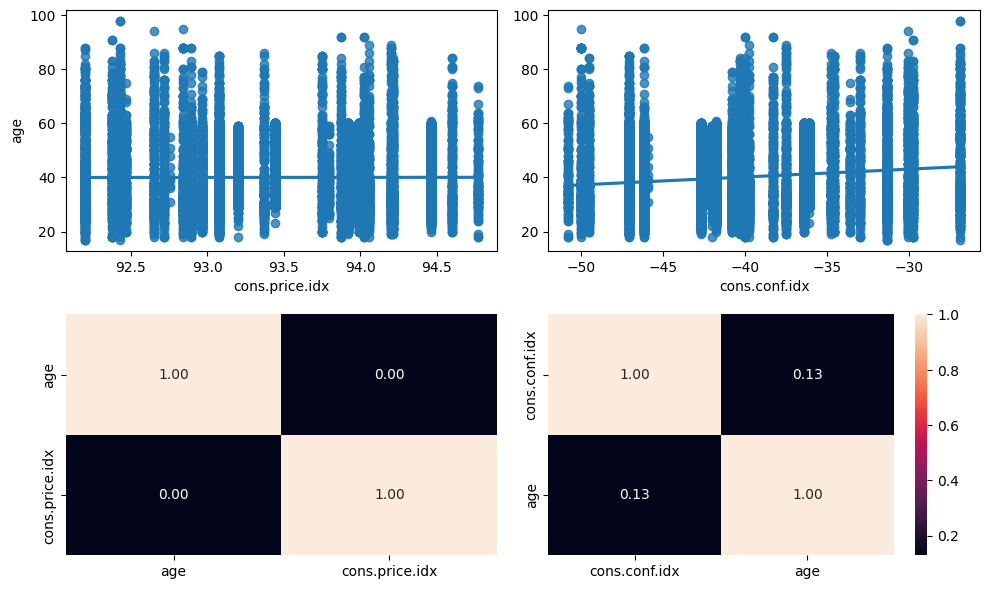

In [16]:
fig, axis = plt.subplots(2, 2, figsize = (10, 6))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "cons.price.idx", y = "age")
sns.heatmap(df[["age", "cons.price.idx"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "cons.conf.idx", y = "age").set(ylabel=None)
sns.heatmap(df[["cons.conf.idx", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

conclusiones age-indice economicos:

- age vs cons.price.idx: El gráfico muestra que no existe una relación fuerte entre la edad del cliente y el índice de precios al consumidor. La línea de regresión es prácticamente plana y la correlación es 0.00, lo que dice que las variables son independiente.

- age vs cons.conf.idx: La correlación es muy baja (0.13), esto quiere decir que la edad del cliente apenas tiene relación co el índice de confianza del consumidor.

euribor3m -(emp.var.rate,nr.employed)

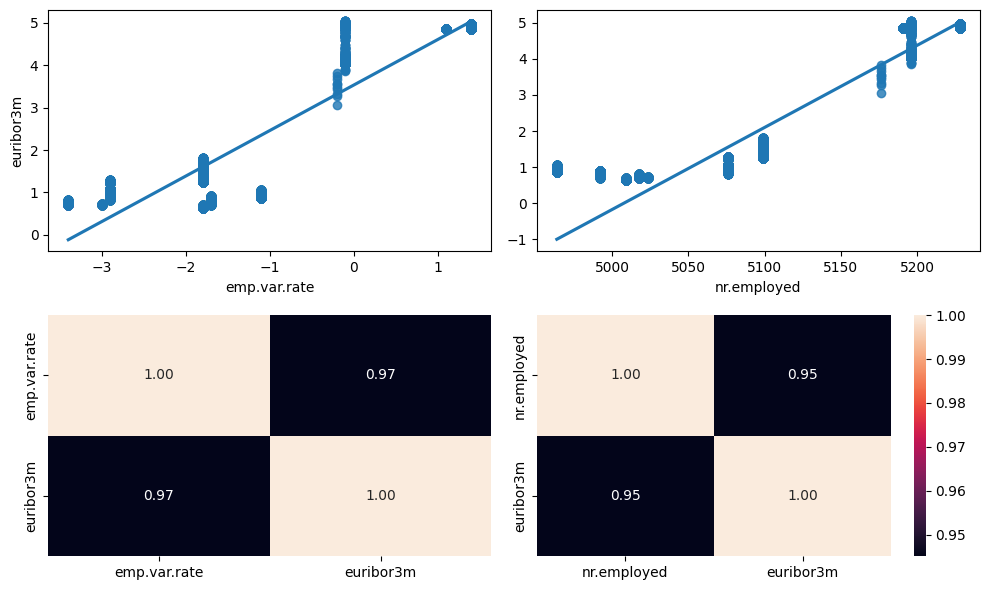

In [17]:
fig, axis = plt.subplots(2, 2, figsize = (10, 6))

# Crear un diagrama de dispersión múltiple
sns.regplot(ax = axis[0, 0], data = df, x = "emp.var.rate", y = "euribor3m")
sns.heatmap(df[["emp.var.rate", "euribor3m"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(ax = axis[0, 1], data = df, x = "nr.employed", y = "euribor3m").set(ylabel=None)
sns.heatmap(df[["nr.employed", "euribor3m"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1])

# Ajustar el layout
plt.tight_layout()

# Mostrar el plot
plt.show()

conclusiones euribor3m vs indicadores económicos:

- euribor3m vs emp.var.rate: Se visualiza una correlación fuerte de 0.97 con tendencia positiva. Cuando la tasa de variación del empleo sube, el euribor también sube. 


- euribor3m vs nr.employed: También muestra una correlación fuerte de 0.95. A mayor número de empleados, mayor euribor. Estos tres indicadores económicos están muy relacionados entre sí.


6. Análisis categórico-categórico

y- (job,education,default,marital,housing,loan,contact,month)

/tmp/ipykernel_994/511850954.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90)
/tmp/ipykernel_994/511850954.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0, 2].set_xticklabels(axis[0, 2].get_xticklabels(), rotation=90)


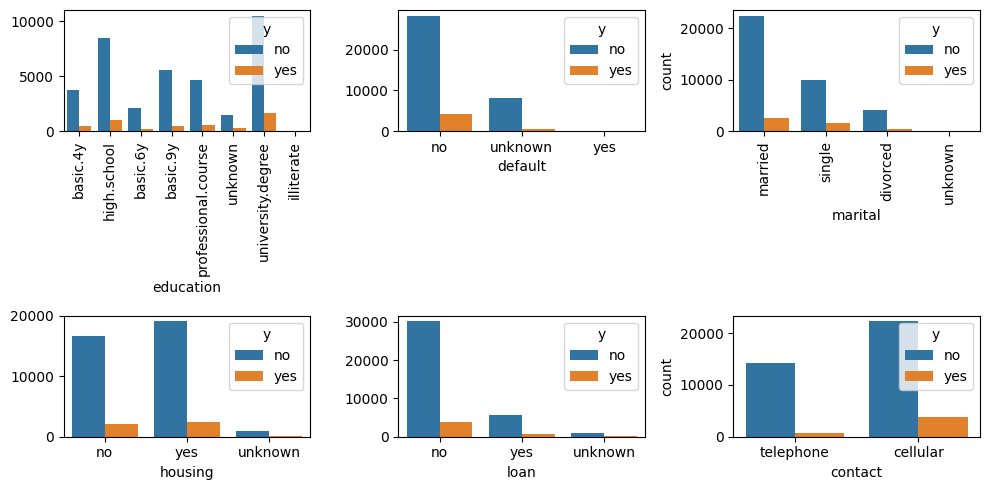

In [18]:
fig, axis = plt.subplots(2, 3, figsize = (10, 5))

sns.countplot(ax = axis[0, 0], data = df, x = "education", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 1], data = df, x = "default", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[0, 2], data = df, x = "marital", hue = "y")
sns.countplot(ax = axis[1, 0], data = df, x = "housing", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 1], data = df, x = "loan", hue = "y").set(ylabel = None)
sns.countplot(ax = axis[1, 2], data = df, x = "contact", hue = "y")
#rotar etiquetas
axis[0, 0].set_xticklabels(axis[0, 0].get_xticklabels(), rotation=90) 
axis[0, 2].set_xticklabels(axis[0, 2].get_xticklabels(), rotation=90) 
plt.tight_layout()

plt.show()

/tmp/ipykernel_994/2781142988.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45)
/tmp/ipykernel_994/2781142988.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axis[1].set_xticklabels(axis[1].get_xticklabels(), rotation=45)


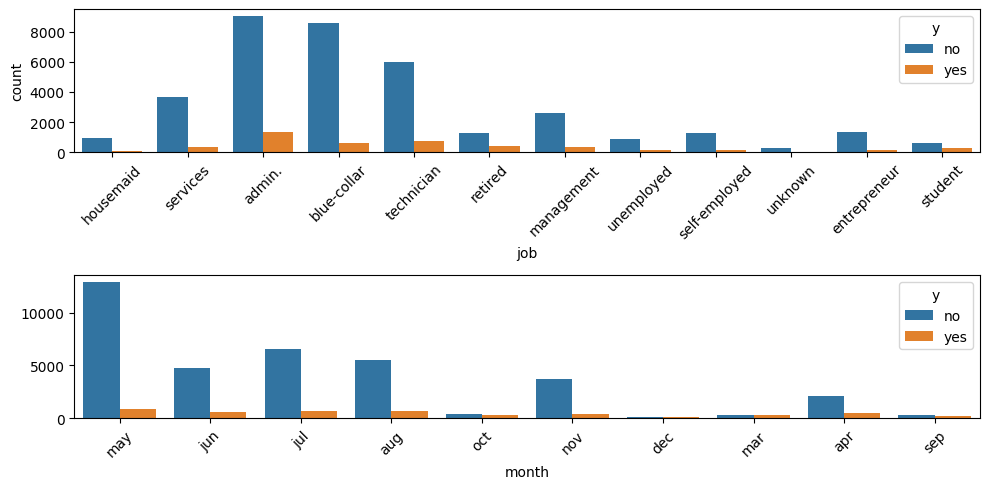

In [19]:
fig, axis = plt.subplots(2, 1, figsize = (10, 5))

sns.countplot(ax = axis[0], data = df, x = "job", hue = "y")

sns.countplot(ax = axis[1], data = df, x = "month", hue = "y").set(ylabel = None)



axis[0].set_xticklabels(axis[0].get_xticklabels(), rotation=45) 
axis[1].set_xticklabels(axis[1].get_xticklabels(), rotation=45) 

plt.tight_layout()

plt.show()

conclusiones:
1. Education vs y
- Si bien es cierto, los registros se concentran más en clientes con highschool y university_degree. Sin embargo, los clientes con grado universitario fueron los que muestran más contratos de depósito a largo plazo en comparación a los demás.
- La categoría "illiterate" presenta muy pocos registros, por lo que se puede decir que no aporta valor para el estudio.

2. Default vs y
- La mayoría de los clientes no cuenta con un crédito.
- La categoría yes contiene muy pocos registros.

3. Marital vs y
- No hay muchos registros de clientes que si contrataron depósito, sin embargo, de los que si tienen el producto financiero son casados.

4. Housing vs y
- Los clientes que presentan préstamo hipotecario son los que tienen relativamente mas cantidad de respuestas positivas al contrato de depósito.

5. Loan vs y
- Los clientes sin préstamo personal concentran la mayor cantidad de respuestas "yes".

6. Contact vs y
- El canal de contacto celular presenta una cantidad mayor de respuestas positivas en comparación con telephone. 

7. month vs y
- Si bien en mayo se contacto a muchos clientes. El resultado de los que respondieronn yes al producto financiero fue bajo.

8. job vs y
- los clientes con ocupaciónn admin son los que tienen más respuestas positivas para el contrato del depósito.

Conclusión final:
- Variables como "contact", "loan", "marital", "month","job" y "education" muestran patrones visuales relevantes para el objetivo del estudio
- La variable default no parece aportar mucha información.

ANNÁLISIS DE CORRELACIONES

In [20]:
#Se factoriza 
df["y_n"] = pd.factorize(df["y"])[0]

# Factorizar 
df["loan_n"] = pd.factorize(df["loan"])[0]

df["job_n"] = pd.factorize(df["job"])[0]

df["month_n"] = pd.factorize(df["month"])[0]

df["education_n"] = pd.factorize(df["education"])[0]

df.head()

,age,job,marital,education,default,housing,loan,contact,month,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_n,loan_n,job_n,month_n,education_n
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,1,...,93.994,-36.4,4.857,5191.0,no,0,0,0,0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,1,...,93.994,-36.4,4.857,5191.0,no,0,0,1,0,1
2,37,services,married,high.school,no,yes,no,telephone,may,1,...,93.994,-36.4,4.857,5191.0,no,0,0,1,0,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,1,...,93.994,-36.4,4.857,5191.0,no,0,0,2,0,2
4,56,services,married,high.school,no,no,yes,telephone,may,1,...,93.994,-36.4,4.857,5191.0,no,0,1,1,0,1


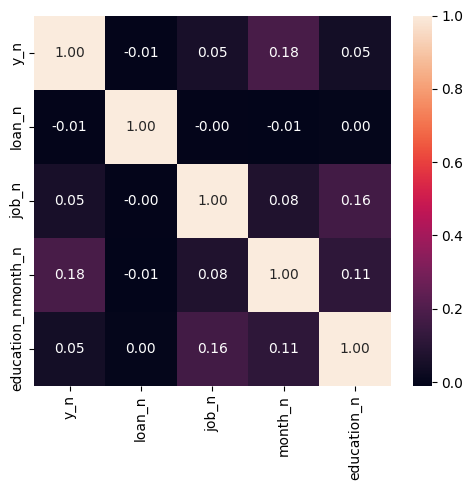

In [21]:
fig, axis = plt.subplots(figsize = (5, 5))

sns.heatmap(df[["y_n", "loan_n", "job_n", "month_n", "education_n"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

no se encuentra ninguna relación entre variables categóricas.

#### 5.3. Análisis numérico-categórico (completo)

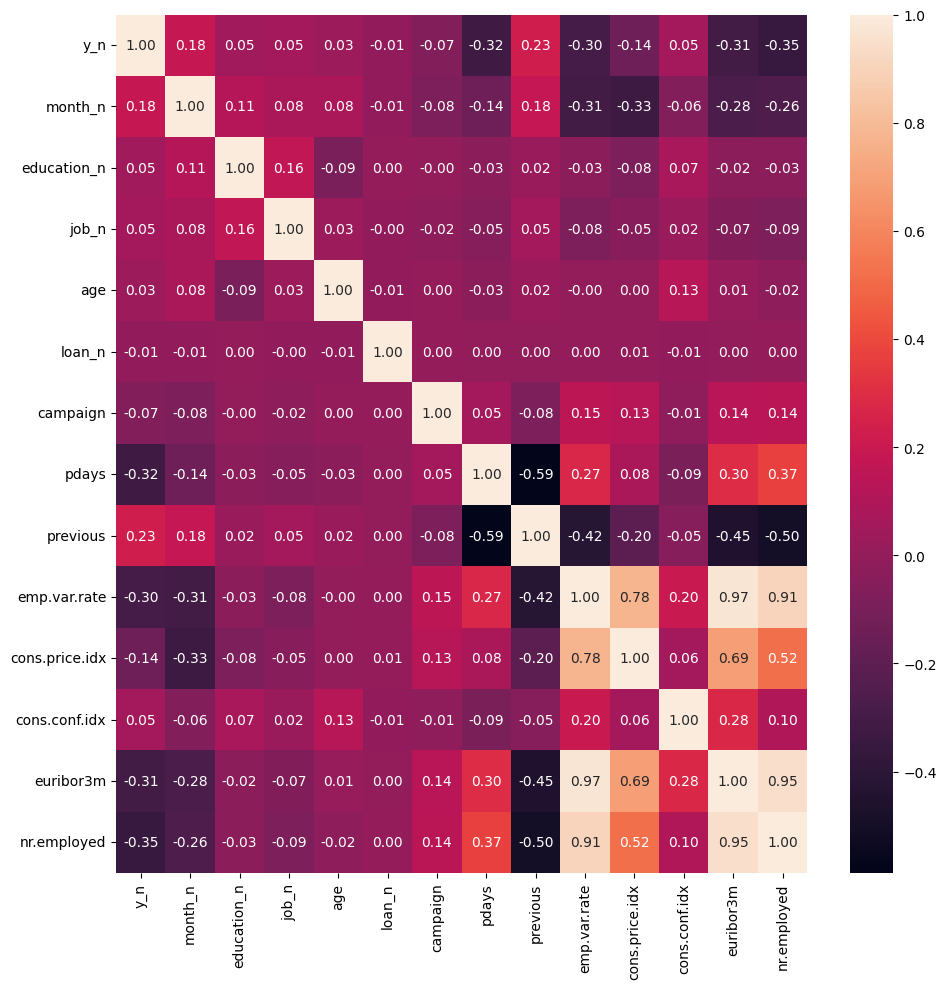

In [22]:
fig, axis = plt.subplots(figsize = (10, 10))

sns.heatmap(df[["y_n","month_n","education_n","job_n", "age","loan_n", "campaign", "pdays", "previous","emp.var.rate","cons.price.idx","cons.conf.idx","euribor3m","nr.employed"]].corr(), annot = True, fmt = ".2f")

plt.tight_layout()

plt.show()

En el análisis numérico-categórico se visualiza correlación fuerte entre las variables:

emp.var.rate vs euribor3m   | 0.97        
euribor3m vs nr.employed    | 0.95        
emp.var.rate vs nr.employed | 0.91        

Como se visualizó ya en el análisis numérico-numérico.
A continuación, se visualizarán los gráficos de dispersión de las variables con correlación fuerte.


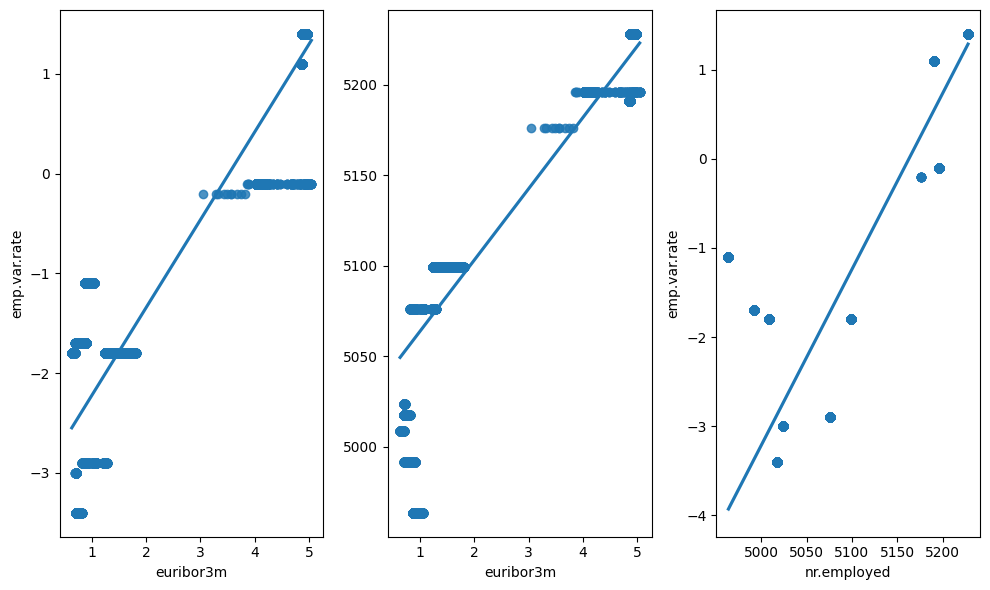

In [23]:
fig, axis = plt.subplots(1, 3, figsize=(10, 6))

sns.regplot(ax=axis[0], data=df, x="euribor3m", y="emp.var.rate")

sns.regplot(ax=axis[1],data=df,x="euribor3m",y="nr.employed").set(ylabel=None)

sns.regplot(ax=axis[2],data=df,x="nr.employed",y="emp.var.rate")

plt.tight_layout()
plt.show()

Conclusión:
Se visualizan que las variables tienen una correlación fuerte con tendencia positiva.Esto tiene mucho sentido ya que las 3 variables son índices económicos. 
Por ejemplo, a medida que aumenta el número de empleados , también tienden a incrementarse variables como la tasa de variación del empleo. 

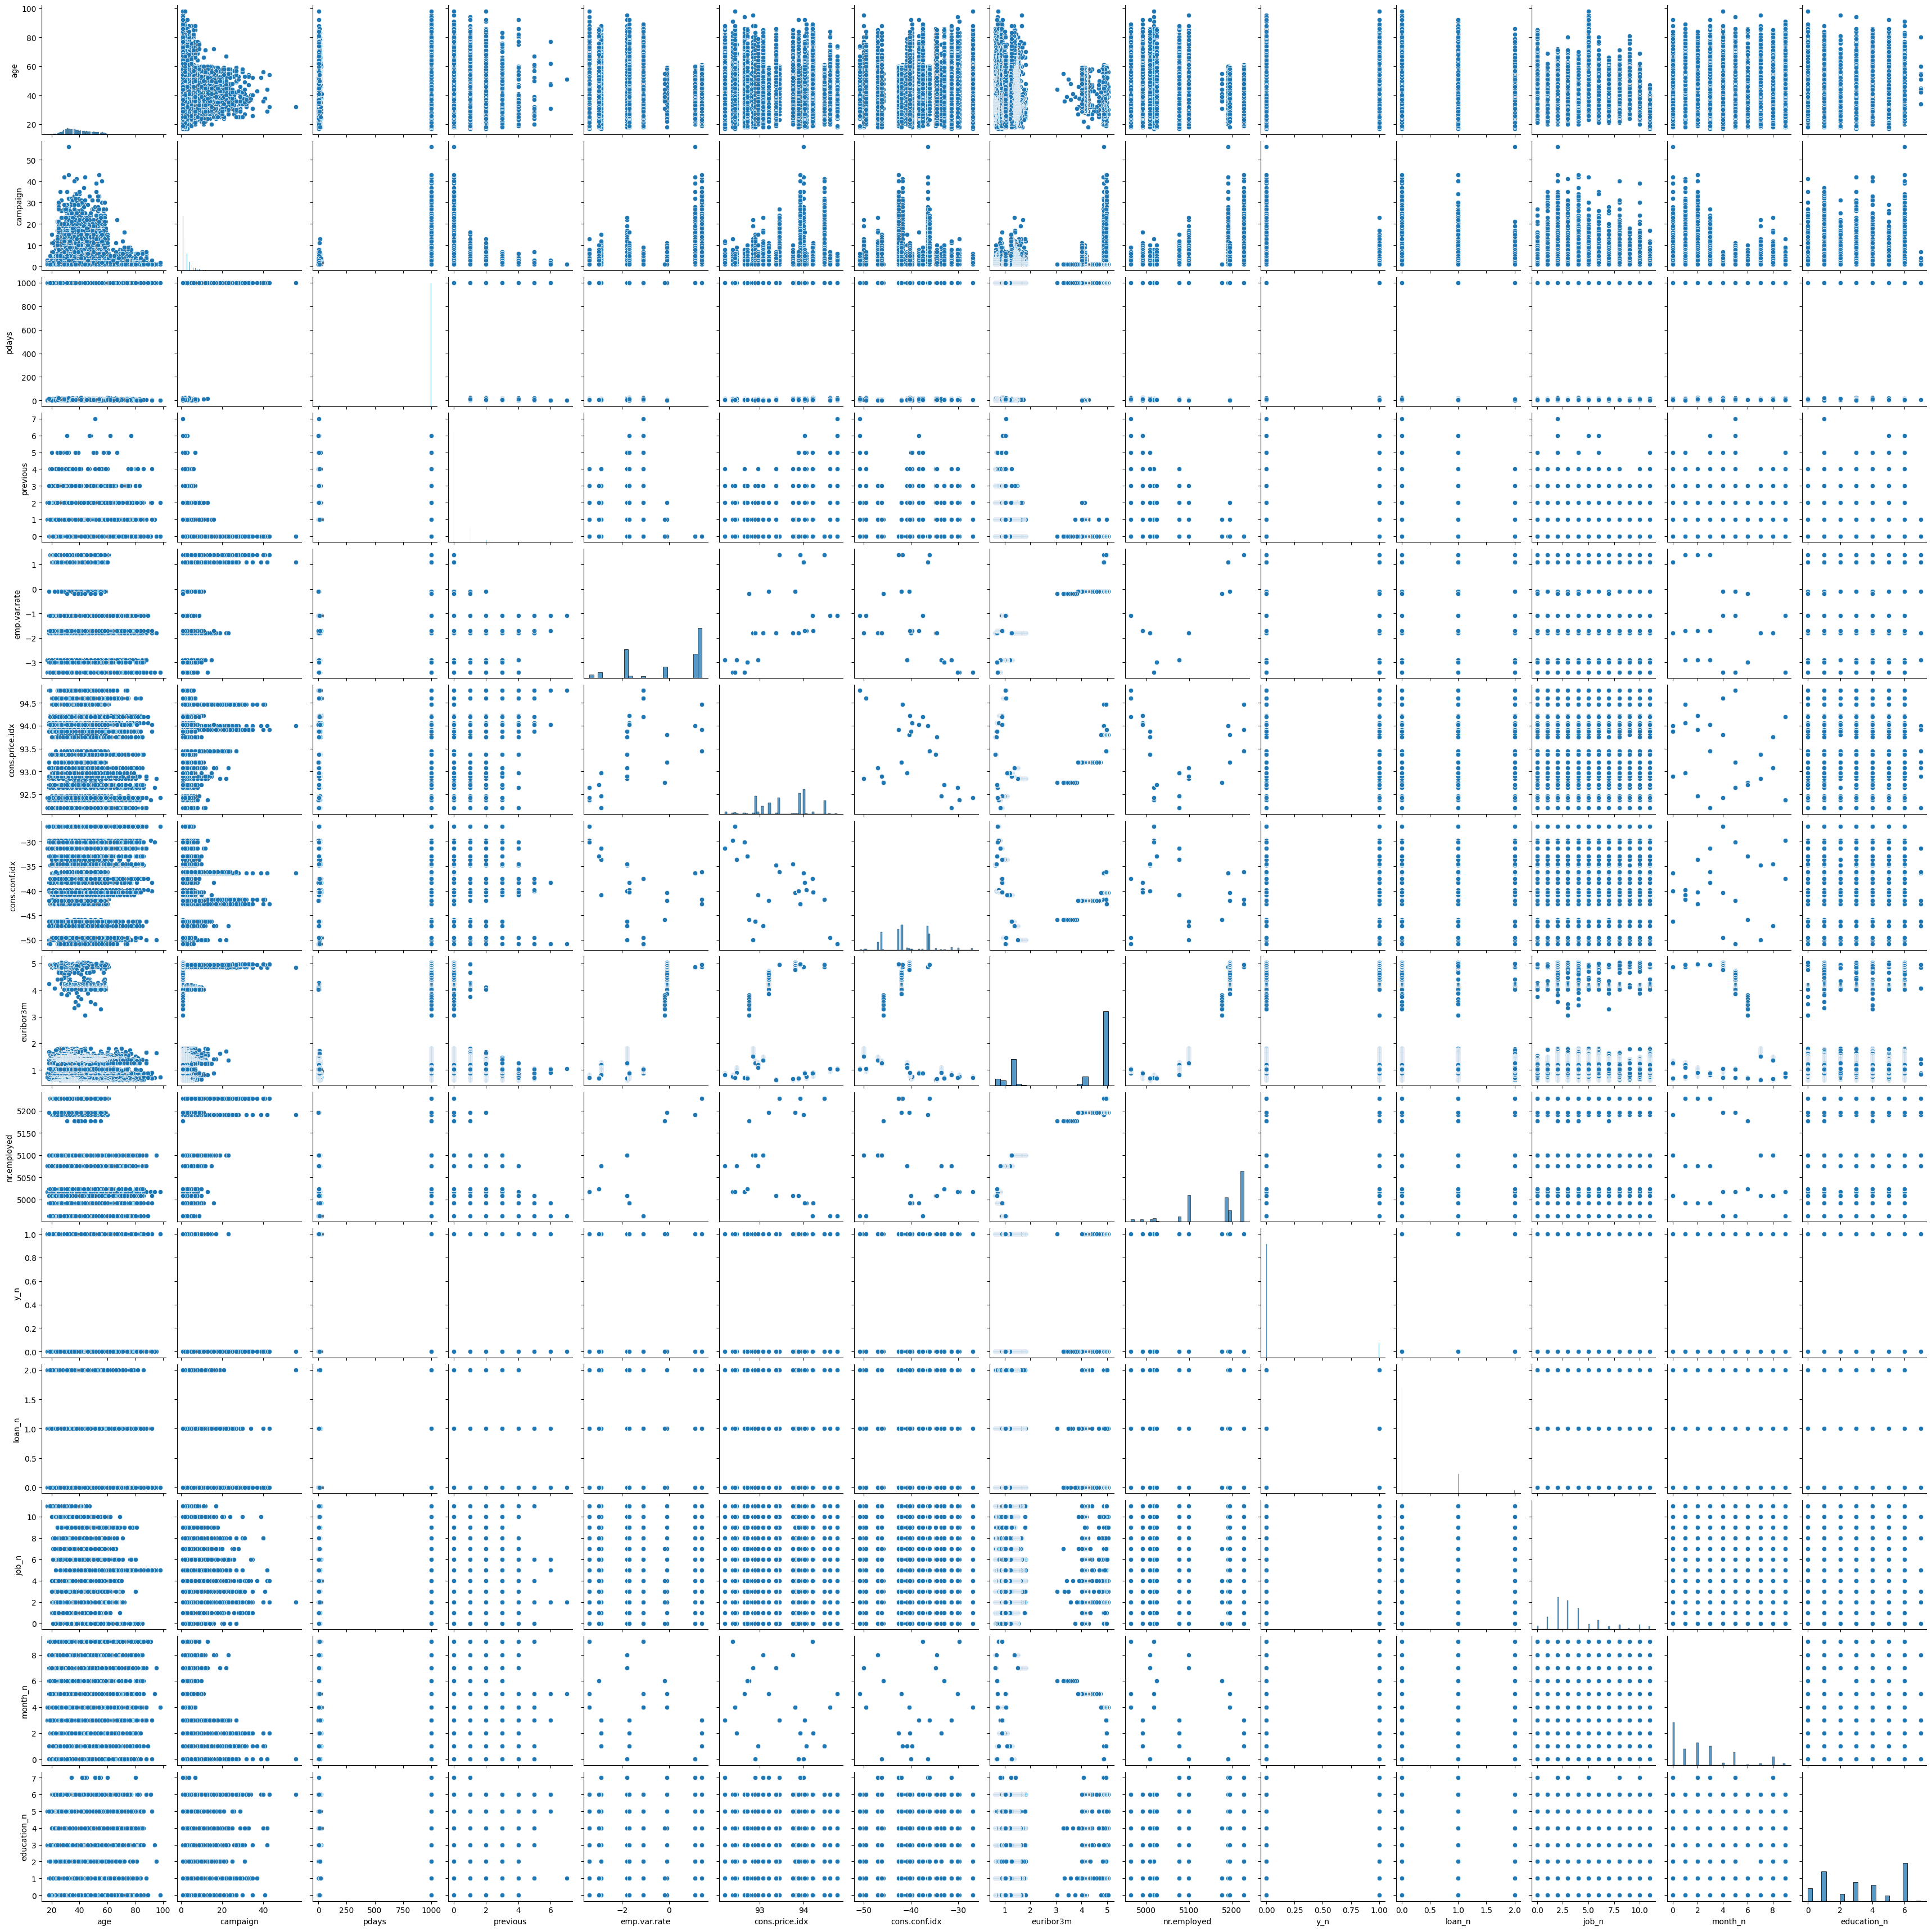

In [24]:
sns.pairplot(data = df)

PARTE 2

1. Valores atípicos

In [25]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n,loan_n,job_n,month_n,education_n
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.112663,0.199825,3.673863,2.249951,3.277370
std,10.42068,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.316184,0.456055,2.454340,2.429157,2.185558
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000,0.000000,2.000000,0.000000,1.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000,0.000000,3.000000,2.000000,3.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000,0.000000,4.000000,3.000000,6.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000,2.000000,11.000000,9.000000,7.000000



conclusiones:

- La edad promedio de los clientes es aprox. 40 años, aunque existen valores extremos entre 17 y 98 años, lo que puede indicar presencia de outliers.

- Campaign presenta una media de 2.56 contactos por cliente, pero un valor máximo de 56 contactos, esto indica posible presencia de outliers o una estrategia de contacto intensivo a clientes.

- pdays tiene percentiles muy concentrados en 999, esto puede indicar que la mayoría de clientes no han sido contactados anteiormente.

- previous muestra que la mayoría de clientes no tuvieron contactos anteriores, ya que tanto el percentil 25, 50 y 75 son 0.

- emp.var.rate, euribor3m y nr.employed no presentan tanta variabilidad en sus datos estadísticos.


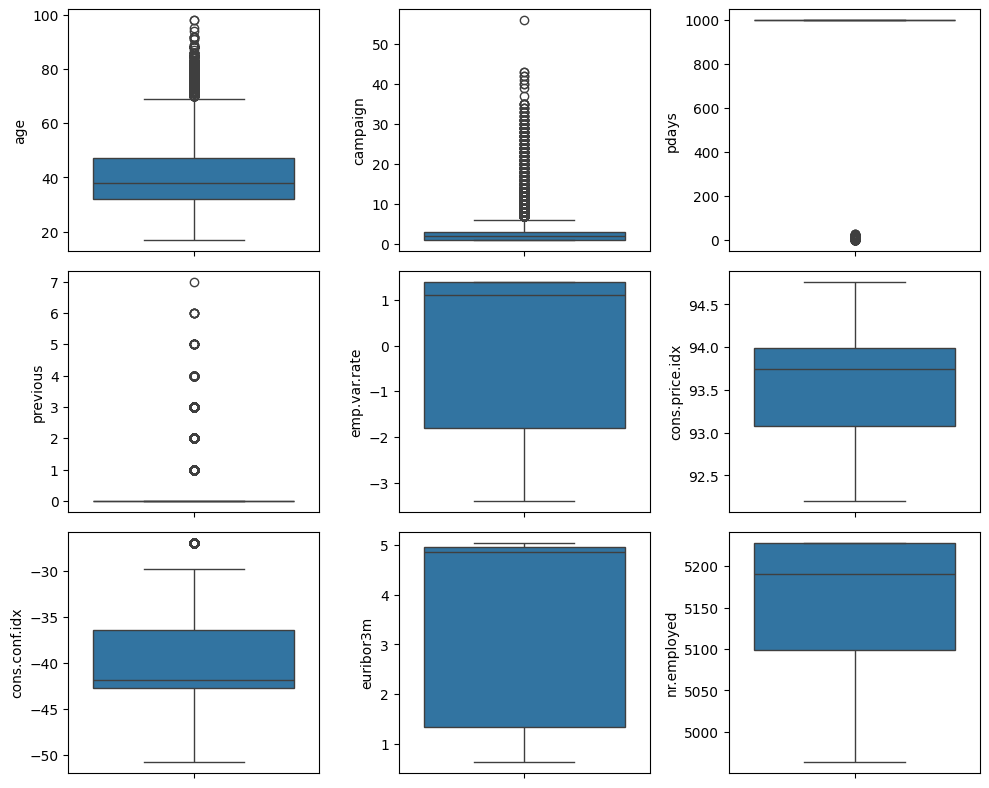

In [26]:
fig, axis = plt.subplots(3, 3, figsize=(10, 8))

sns.boxplot(ax=axis[0, 0], data=df, y="age")
sns.boxplot(ax=axis[0, 1], data=df, y="campaign")
sns.boxplot(ax=axis[0, 2], data=df, y="pdays")

sns.boxplot(ax=axis[1, 0], data=df, y="previous")
sns.boxplot(ax=axis[1, 1], data=df, y="emp.var.rate")
sns.boxplot(ax=axis[1, 2], data=df, y="cons.price.idx")

sns.boxplot(ax=axis[2, 0], data=df, y="cons.conf.idx")
sns.boxplot(ax=axis[2, 1], data=df, y="euribor3m")
sns.boxplot(ax=axis[2, 2], data=df, y="nr.employed")

plt.tight_layout()
plt.show()

Las variables afectadas por outliers son age y campaign (no estudiaremos padays porque si tiene valores 999 esto no necesariamente es un outlier normmal, indica que el cliente no se ha contactado antes, por ello no se valorará para el análisis de atípicos)
Tampoco se evaluará previous por los datos alrededor de 0.

atipicos-age

In [27]:
# Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites inferior y superior
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(IQR, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 69.5 y 9.5, con un rango intercuartílico de 15.0


Aquí se tiene que las edades mayor de 69.5 se consideran outliers. por lo que se revisará los registros que ocupan estos atípicos.

In [28]:
#se coloca el redondeo de 69.5=70
edad_alta = df[df["age"] >= 70]

edad_alta

,age,job,marital,education,default,housing,loan,contact,month,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_n,loan_n,job_n,month_n,education_n
27705,70,retired,divorced,basic.4y,no,yes,no,cellular,mar,3,...,92.843,-50.0,1.811,5099.1,yes,1,0,5,7,0
27749,76,retired,married,university.degree,no,no,yes,cellular,mar,9,...,92.843,-50.0,1.757,5099.1,no,0,1,5,7,6
27772,73,retired,married,university.degree,no,yes,no,cellular,mar,1,...,92.843,-50.0,1.687,5099.1,no,0,0,5,7,6
27792,88,retired,divorced,basic.4y,no,yes,no,cellular,mar,1,...,92.843,-50.0,1.663,5099.1,no,0,0,5,7,0
27794,88,retired,divorced,basic.4y,no,no,no,cellular,mar,2,...,92.843,-50.0,1.663,5099.1,yes,1,0,5,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40974,84,retired,divorced,basic.4y,unknown,yes,yes,cellular,oct,4,...,94.601,-49.5,1.000,4963.6,no,0,1,5,4,0
40984,81,retired,married,basic.4y,no,yes,no,cellular,oct,1,...,94.601,-49.5,1.016,4963.6,yes,1,0,5,4,0
40992,80,retired,married,professional.course,no,yes,no,cellular,oct,1,...,94.601,-49.5,1.025,4963.6,yes,1,0,5,4,4
41171,73,retired,married,professional.course,no,yes,no,cellular,nov,1,...,94.767,-50.8,1.028,4963.6,yes,1,0,5,5,4


Se visualiza que los outlier de edad (>70) son 468 lo que equivale un 1% del dataset, por lo que se decide ekiminarlos.

In [29]:
df = df[df["age"] < 70]
df.shape

(40708, 24)

atipicos-campaign

In [30]:
# Calcular el primer cuartil (Q1) y el tercer cuartil (Q3)
Q1_ = df['campaign'].quantile(0.25)
Q3_ = df['campaign'].quantile(0.75)
IQR_ = Q3_ - Q1_

# Definir los límites inferior y superior
lower_limit_c = Q1_ - 1.5 * IQR_
upper_limit_c = Q3_ + 1.5 * IQR_

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_c, 2)} y {round(lower_limit_c, 2)}, con un rango intercuartílico de {round(IQR_, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 6.0 y -2.0, con un rango intercuartílico de 2.0


In [31]:
# Definir los límites inferior y superior, se utiliza 3* en ves de 1.5* que se usaba en el script anterior
lower_limit_c = Q1_ - 3 * IQR_
upper_limit_c = Q3_ + 3 * IQR_

print(f"Los límites superior e inferior para la búsqueda de outliers son {round(upper_limit_c, 2)} y {round(lower_limit_c, 2)}, con un rango intercuartílico de {round(IQR_, 2)}")

Los límites superior e inferior para la búsqueda de outliers son 9.0 y -5.0, con un rango intercuartílico de 2.0


In [32]:

campaign_alto = df[df["campaign"] >= 9]

campaign_alto

,age,job,marital,education,default,housing,loan,contact,month,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y_n,loan_n,job_n,month_n,education_n
1466,38,admin.,single,university.degree,no,no,no,telephone,may,9,...,93.994,-36.4,4.855,5191.0,no,0,0,2,0,6
1483,38,blue-collar,married,basic.6y,no,no,no,telephone,may,9,...,93.994,-36.4,4.855,5191.0,no,0,0,3,0,2
1865,54,management,married,basic.4y,unknown,no,no,telephone,may,9,...,93.994,-36.4,4.855,5191.0,no,0,0,6,0,0
1979,37,technician,married,professional.course,no,yes,no,telephone,may,9,...,93.994,-36.4,4.855,5191.0,no,0,0,4,0,4
2182,58,management,married,university.degree,no,no,no,telephone,may,10,...,93.994,-36.4,4.857,5191.0,no,0,0,6,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39507,24,blue-collar,single,high.school,no,no,no,cellular,apr,10,...,93.749,-34.6,0.645,5008.7,no,0,0,3,8,1
40051,21,student,single,unknown,no,yes,yes,cellular,jul,11,...,94.215,-40.3,0.810,4991.6,no,0,1,11,2,5
40079,39,admin.,divorced,university.degree,no,yes,yes,cellular,jul,10,...,94.215,-40.3,0.827,4991.6,yes,1,1,2,2,6
40136,30,student,single,professional.course,no,yes,no,telephone,jul,9,...,94.215,-40.3,0.840,4991.6,no,0,0,11,2,4


Según lo realizado, se hicieron dos chequeo de outliers interquartílicos del cual se definieron valores mamyores a 9 como atìpicos. el dataset de dicha segmentación equival ea 1372 filas (3% del dataset)
Por lo que, se define eliminar esos outliers, podrían afectar al modelo predictivo.

In [33]:
df = df[df["campaign"] < 9]
df.shape

(39336, 24)

2. Valores faltantes

In [34]:
df.isnull().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_n               0
loan_n            0
job_n             0
month_n           0
education_n       0
dtype: int64

Conclusión: no hay valores nulos en le dataset

In [35]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
y_n               0
loan_n            0
job_n             0
month_n           0
education_n       0
dtype: int64

2. Ingeniería de atributos

In [36]:
df['pdays'].value_counts()

pdays
999    37921
3        399
6        382
4        111
2         60
9         59
12        56
7         55
10        51
5         45
13        34
11        28
1         26
15        22
8         17
14        17
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

Se propone hacer una segmentación con el valor pdays, que agrupe en contactado y no contactado (si es 999 no fue contactado antes )

In [37]:
#nueva columna pdays
df['pdays_resumen'] = (df['pdays'] != 999).astype(int)

# Verificar el resultado
print(df['pdays_resumen'].value_counts())

pdays_resumen
0    37921
1     1415
Name: count, dtype: int64


3. train/test split
Dividir el dataset en train y test

80% → entrenamiento

20% → prueba

In [38]:
X=df.drop("y",axis=1)   #variable predictora
y=df["y"]               #variable objetivo


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.head()

,age,job,marital,education,default,housing,loan,contact,month,campaign,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n,loan_n,job_n,month_n,education_n,pdays_resumen
26834,43,technician,single,professional.course,unknown,unknown,unknown,cellular,nov,3,...,93.200,-42.0,4.076,5195.8,0,2,4,5,4,0
26377,32,unemployed,single,high.school,no,yes,no,cellular,nov,4,...,93.200,-42.0,4.076,5195.8,0,0,7,5,1,0
35839,36,admin.,married,professional.course,no,yes,yes,cellular,may,1,...,92.893,-46.2,1.259,5099.1,0,1,2,0,4,0
39660,32,admin.,married,university.degree,no,no,no,telephone,may,4,...,93.876,-40.0,0.684,5008.7,0,0,2,0,6,0
12376,55,admin.,married,high.school,no,yes,no,cellular,jul,3,...,93.918,-42.7,4.960,5228.1,0,0,2,2,1,0


In [39]:
X_train.shape, X_test.shape

((31468, 24), (7868, 24))

4. Escalado

Se realiza el escalado de variables numéricas mediante `StandardScaler`, con el fin de normalizar los datos y llevarlos a una escala comparable.

In [40]:
#variables numéricas
num_variables = [
    "age",
    "campaign",
    "pdays",
    "previous",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed",
    "pdays_resumen"
]

In [41]:
# instancio el escalador
scaler = StandardScaler()

# entreno el escalador con los datos de entrenamiento
scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_scal = scaler.transform(X_train[num_variables])
X_train_num_scal = pd.DataFrame(X_train_num_scal, index = X_train.index, columns = num_variables)

X_test_num_scal = scaler.transform(X_test[num_variables])
X_test_num_scal = pd.DataFrame(X_test_num_scal, index = X_test.index, columns = num_variables)

X_train_num_scal.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_resumen
26834,0.355186,0.533723,0.192017,-0.352763,-0.111641,-0.644797,-0.309046,0.265784,0.401418,-0.192018
26377,-0.779973,1.191224,0.192017,-0.352763,-0.111641,-0.644797,-0.309046,0.265784,0.401418,-0.192018
35839,-0.367188,-0.781279,0.192017,-0.352763,-1.199566,-1.178675,-1.222394,-1.363348,-0.951030,-0.192018
39660,-0.779973,1.191224,0.192017,1.699888,-1.199566,0.530778,0.125882,-1.695883,-2.215366,-0.192018
12376,1.593540,0.533723,0.192017,-0.352763,0.848294,0.603817,-0.461270,0.777021,0.853167,-0.192018


In [42]:
# instancio el escalador
scaler = MinMaxScaler()

# entreno el escalador con los datos de entrenamiento

scaler.fit(X_train[num_variables])

# aplico el escalador en amhos
X_train_num_mm = scaler.transform(X_train[num_variables])
X_train_num_mm = pd.DataFrame(X_train_num_mm, index = X_train.index, columns = num_variables)

X_test_num_mm = scaler.transform(X_test[num_variables])
X_test_num_mm = pd.DataFrame(X_test_num_mm, index = X_test.index, columns = num_variables)

X_train_num_mm.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_resumen
26834,0.500000,0.285714,1.0,0.000000,0.687500,0.389322,0.368201,0.780322,0.877883,0.0
26377,0.288462,0.428571,1.0,0.000000,0.687500,0.389322,0.368201,0.780322,0.877883,0.0
35839,0.365385,0.000000,1.0,0.000000,0.333333,0.269680,0.192469,0.141691,0.512287,0.0
39660,0.288462,0.428571,1.0,0.142857,0.333333,0.652767,0.451883,0.011335,0.170510,0.0
12376,0.730769,0.285714,1.0,0.000000,1.000000,0.669135,0.338912,0.980730,1.000000,0.0


5. encoding

Las variables categóricas, que contienen valores discretos y no numéricos, deben transformarse en una forma que los algoritmos de ML puedan entender.

Existen varias técnicas de codificación, cada una con sus ventajas y desventajas, dependiendo del tipo de datos y del modelo utilizado.

Se usará la técnica de one-hot encoding  por que los datos no tienen orden natural

In [43]:
cat_variables = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

In [44]:
# instancio el encoder

onehot_encoder = OneHotEncoder(sparse_output=False)

# entreno el encoder con los datos de entrenamiento
onehot_encoder.fit(X_train[cat_variables])

# aplico el encoder en amhos
X_train_cat_ohe = onehot_encoder.transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe, index = X_train.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_test_cat_ohe = onehot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe, index = X_test.index, columns=onehot_encoder.get_feature_names_out(cat_variables))

X_train_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success
26834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
26377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
35839,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
39660,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
12376,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


PARTE 3

1. Selección de características

En esta parte se usa estadístico de prueba para seleccionar las variables importantes


unificar dataset preprocesado

In [45]:
# unificamos el dataset preprocesado hasta el momento
X_train_final = pd.concat([X_train_num_scal, X_train_cat_ohe], axis=1)
X_test_final = pd.concat([X_test_num_scal, X_test_cat_ohe], axis=1)

X_train_final.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_resumen,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_nonexistent,poutcome_success
26834,0.355186,0.533723,0.192017,-0.352763,-0.111641,-0.644797,-0.309046,0.265784,0.401418,-0.192018,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
26377,-0.779973,1.191224,0.192017,-0.352763,-0.111641,-0.644797,-0.309046,0.265784,0.401418,-0.192018,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
35839,-0.367188,-0.781279,0.192017,-0.352763,-1.199566,-1.178675,-1.222394,-1.363348,-0.951030,-0.192018,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
39660,-0.779973,1.191224,0.192017,1.699888,-1.199566,0.530778,0.125882,-1.695883,-2.215366,-0.192018,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
12376,1.593540,0.533723,0.192017,-0.352763,0.848294,0.603817,-0.461270,0.777021,0.853167,-0.192018,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Se aplicó SelectKBest con el estadístico f_classif para seleccionar las variables más relevantes.

In [46]:

# Seleccionar las 20 variables más importantes
selection_model = SelectKBest(score_func = f_classif, k = 20)

# Entrenar el selector
selection_model.fit(X_train_final, y_train)

# Obtener columnas seleccionadas
ix = selection_model.get_support()

# Transformar datasets
X_train_sel = pd.DataFrame(selection_model.transform(X_train_final),columns = X_train_final.columns.values[ix],index = X_train_final.index)

X_test_sel = pd.DataFrame(selection_model.transform(X_test_final),columns = X_test_final.columns.values[ix],
    index = X_test_final.index)

X_train_sel.head()

,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,pdays_resumen,job_student,default_no,default_unknown,contact_cellular,contact_telephone,month_apr,month_dec,month_mar,month_may,month_oct,month_sep,poutcome_nonexistent,poutcome_success
26834,0.192017,-0.352763,-0.111641,-0.644797,0.265784,0.401418,-0.192018,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
26377,0.192017,-0.352763,-0.111641,-0.644797,0.265784,0.401418,-0.192018,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
35839,0.192017,-0.352763,-1.199566,-1.178675,-1.363348,-0.951030,-0.192018,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
39660,0.192017,1.699888,-1.199566,0.530778,-1.695883,-2.215366,-0.192018,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12376,0.192017,-0.352763,0.848294,0.603817,0.777021,0.853167,-0.192018,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [47]:
# Obtener las características seleccionadas
selected_features = X_train_final.columns[selection_model.get_support()]

selected_features

Index(['pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'euribor3m',
       'nr.employed', 'pdays_resumen', 'job_student', 'default_no',
       'default_unknown', 'contact_cellular', 'contact_telephone', 'month_apr',
       'month_dec', 'month_mar', 'month_may', 'month_oct', 'month_sep',
       'poutcome_nonexistent', 'poutcome_success'],
      dtype='str')

In [48]:
X_train_sel["y"] = y_train.values
X_test_sel["y"] = y_test.values

X_train_sel.to_csv("../data/processed/clean_train.csv", index=False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index=False)

MODELADO

In [49]:
#traer la data preprocesada
train_data=pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")

train_data.head()

,pdays,previous,emp.var.rate,cons.price.idx,euribor3m,nr.employed,pdays_resumen,job_student,default_no,default_unknown,...,contact_telephone,month_apr,month_dec,month_mar,month_may,month_oct,month_sep,poutcome_nonexistent,poutcome_success,y
0,0.192017,-0.352763,-0.111641,-0.644797,0.265784,0.401418,-0.192018,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no
1,0.192017,-0.352763,-0.111641,-0.644797,0.265784,0.401418,-0.192018,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no
2,0.192017,-0.352763,-1.199566,-1.178675,-1.363348,-0.951030,-0.192018,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,no
3,0.192017,1.699888,-1.199566,0.530778,-1.695883,-2.215366,-0.192018,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,no
4,0.192017,-0.352763,0.848294,0.603817,0.777021,0.853167,-0.192018,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,no


separar X, y

In [50]:
# Separar X e y
X_train = train_data.drop(["y"], axis = 1)
y_train = train_data["y"]

X_test = test_data.drop(["y"], axis = 1)
y_test = test_data["y"]

inicialización y entrenamiento del modelo

In [51]:
model = LogisticRegression(solver = 'liblinear')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

 Predicción del modelo

In [52]:
y_pred = model.predict(X_test)
y_pred

array(['yes', 'no', 'no', ..., 'no', 'no', 'no'],
      shape=(7868,), dtype=object)

In [53]:
accuracy_score(y_test, y_pred)

0.9064565327910523

In [54]:
precision_score(y_test, y_pred, pos_label='yes')

0.6788321167883211

In [55]:
recall_score(y_test, y_pred, pos_label='yes')

0.22302158273381295

In [56]:
f1_score(y_test, y_pred, pos_label='yes')

0.33574007220216606

In [57]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n          no       0.91      0.99      0.95      7034\n         yes       0.68      0.22      0.34       834\n\n    accuracy                           0.91      7868\n   macro avg       0.80      0.61      0.64      7868\nweighted avg       0.89      0.91      0.88      7868\n'

In [58]:
nombres_clases = ["No contrata (no)", "Contrata (yes)"]

print(classification_report(
    y_test,
    y_pred,
    target_names=nombres_clases,  # etiquetas legibles
    digits=3,                      # decimales
    zero_division=0                # evita warnings si hay divisiones por 0
))

                  precision    recall  f1-score   support

No contrata (no)      0.915     0.987     0.950      7034
  Contrata (yes)      0.679     0.223     0.336       834

        accuracy                          0.906      7868
       macro avg      0.797     0.605     0.643      7868
    weighted avg      0.890     0.906     0.885      7868



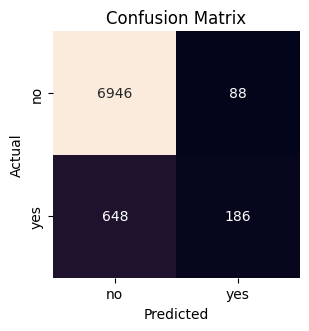

In [59]:
banca_cm = confusion_matrix(y_test, y_pred, labels=["no", "yes"])

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(banca_cm,index=["no", "yes"], columns=["no", "yes"])

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

conclusiones:


Optimización de resultadoso

In [60]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [61]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
  "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"] 
}

# Inicializamos la cuadrícula
grid = GridSearchCV(model, hyperparams, scoring = "f1", cv = 5)
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [62]:
grid.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.001, 'penalty': 'l1', 'solver': 'liblinear'}


In [63]:
model_grid = LogisticRegression(penalty = "l1", C = 0.001, solver = "liblinear")
model_grid.fit(X_train, y_train)
y_pred = model_grid.predict(X_test)

grid_accuracy = accuracy_score(y_test, y_pred)
grid_accuracy

0.9045500762582613

no hay gran mejroa

In [64]:
# Definimos los parámetros que queremos ajustar
hyperparams = {
    "C": np.logspace(-4, 4, 20),
     "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model, hyperparams, n_iter = 100, scoring = "f1", cv = 5, random_state = 42)
random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...r='liblinear')
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` defaul

In [65]:
random_search.fit(X_train, y_train)

print(f"Mejores hiperparámetros: {random_search.best_params_}")

Mejores hiperparámetros: {'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.0001)}


In [66]:
model_random_search = LogisticRegression(penalty = "l1", C = 0.0001, solver = "liblinear")
model_random_search.fit(X_train, y_train)
y_pred = model_random_search.predict(X_test)

random_search_accuracy = accuracy_score(y_test, y_pred)
random_search_accuracy

0.8940010167768175